## Resume–Job Description Matching Agent using Siamese BiLSTM

In [ ]:

# =====================================
# Install Required Libraries
# =====================================

!pip install -q nltk
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q tqdm

In [ ]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import tensorflow as tf

print("TensorFlow Version :", tf.__version__)
print("GPU Available :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.20.0
GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import os

print(os.listdir())

['.config', 'train.jsonl', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Resume_JD_Project"

os.makedirs(project_path, exist_ok=True)

print(project_path)

/content/drive/MyDrive/Resume_JD_Project


In [ ]:
import os

print(os.listdir('/content/drive'))

['Shareddrives', '.shortcut-targets-by-id', 'MyDrive', '.Trash-0']


In [ ]:
import os

project_path = "/content/drive/MyDrive/Resume_JD_Project"

print(os.path.exists(project_path))

True


# Module 2: Dataset Loading & Exploration

In [ ]:
import json
import pandas as pd

data = []

with open("train.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)

Dataset Shape: (99615, 8)


In [ ]:
df = pd.DataFrame(data)

print("Shape:", df.shape)

df.head()

Shape: (99615, 8)


,Job-Description,Resume-matched,Resume-unmatched,Skills,Experiences,Experiences-years,Filtered-information,Experienc
0,\n\n## Job Title\nOracle SCM Developer\n\n## J...,\n\n## Personal Information\nName: Konstantina...,\n\n## Personal Information\nName: Konstantina...,"[SQL, ERP, Supply chain, BOM, WIP]","[Oracle SCM Developer, SAP Sales and Supply Ch...","[[[3 years as a Oracle SCM Developer, 1 years ...","{'Skills': ['ERP', 'BOM', 'SQL'], 'Experience'...",NaN
1,"\n\n## Job Title\nElectrical, Electronic, and ...",\n\n## Personal Information\nName: Yelena Belo...,\n\n## Personal Information\nName: Yelena Belo...,"[Medical Knowledge, Technical Skills, Problem-...","[Electrical, electronic, and electromechanical...",[[[4 years as a Electrical - electronic - and ...,"{'Skills': ['Interpersonal Skills', 'Technical...",NaN
2,\n\n## Job Title\nUI - Sr. Java Tech Lead (Por...,\n\n## Personal Information\nName: Matthew Ste...,\n\n## Personal Information\nName: Matthew Jam...,"[ASP. NET, HTML, HTML DOM, Java, Java Service ...",[UI - Sr. Java Tech Lead (Portals) & Sr. UI Ja...,[[[4 years as a UI - Sr. Java Tech Lead (Porta...,"{'Skills': ['Microsoft .NET Framework', 'Java ...",NaN
3,\n\n## Job title\nTechnical Architect- JAVA\n\...,\n\n## Personal Information\nName: Haruna Yaku...,\n\n## Personal Information\nName: Haruna Yaku...,"[JAVA, J2EE, Architect, SOA, Spring MVC, Model...",[Technical Architect- JAVA],"[[[3 years as a Technical Architect- JAVA], [T...","{'Skills': ['web services', 'JAVA', 'J2EE'], '...",NaN
4,\n\n## Job title\nFishing and Hunting Worker\n...,\n\n## Personal Information\nName: Finley Murr...,\n\n## Personal Information\nName: Finley Murr...,"[Emergency Response, Physical Fitness and Stam...","[Fishing and hunting workers, Forest fire insp...","[[[4 years as a Fishing and hunting workers, 2...","{'Skills': ['Emergency Response', 'Incident Co...",NaN


In [ ]:
print(df.columns)

Index(['Job-Description', 'Resume-matched', 'Resume-unmatched', 'Skills',
       'Experiences', 'Experiences-years', 'Filtered-information'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5457 entries, 0 to 5456
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Job-Description       5457 non-null   object
 1   Resume-matched        5454 non-null   object
 2   Resume-unmatched      5456 non-null   object
 3   Skills                5457 non-null   object
 4   Experiences           5457 non-null   object
 5   Experiences-years     5457 non-null   object
 6   Filtered-information  5457 non-null   object
dtypes: object(7)
memory usage: 298.6+ KB


In [ ]:
df.isnull().sum()

,0
Job-Description,0
Resume-matched,3
Resume-unmatched,1
Skills,0
Experiences,0
Experiences-years,0
Filtered-information,0


In [ ]:
sample = df.iloc[0]

print("="*80)
print("JOB DESCRIPTION")
print("="*80)

print(sample["Job-Description"][:1200])

print("\n\n")

print("="*80)
print("MATCHED RESUME")
print("="*80)

print(sample["Resume-matched"][:1200])

print("\n\n")

print("="*80)
print("UNMATCHED RESUME")
print("="*80)

print(sample["Resume-unmatched"][:1200])

In [ ]:
df.dtypes

In [ ]:
df["JD_length"] = df["Job-Description"].apply(len)

df["Matched_length"] = df["Resume-matched"].apply(len)

df["Unmatched_length"] = df["Resume-unmatched"].apply(len)

df[["JD_length","Matched_length","Unmatched_length"]].describe()

## ==========================================
# MODULE 3 : CREATE TRAINING PAIRS
# ==========================================

In [ ]:
# Lists to store the training data

resumes = []
job_descriptions = []
labels = []

for _, row in df.iterrows():

    jd = row["Job-Description"]

    matched_resume = row["Resume-matched"]

    unmatched_resume = row["Resume-unmatched"]

    # Positive pair
    resumes.append(matched_resume)
    job_descriptions.append(jd)
    labels.append(1)

    # Negative pair
    resumes.append(unmatched_resume)
    job_descriptions.append(jd)
    labels.append(0)

print("Total Training Samples:", len(labels))

Total Training Samples: 199230


In [ ]:
print(type(df.iloc[0]["Resume-matched"]))
print(type(df.iloc[0]["Resume-unmatched"]))

<class 'str'>
<class 'str'>


In [ ]:
print(df.iloc[0]["Resume-matched"])



## Personal Information
Name: Konstantina Caruso
Email: KonstantinaCaruso@email.com

## Education
Bachelor’s Degree in Enterprise Resource Planning Systems from a prestigious university.

## Skills
- Expertise in SQL
- Skilled in ERP Integration
- Comprehensive understanding of the supply chain industry
- Knowledgeable in BOM systems
- Experienced in handling WIP specifications and adjustments under tight schedules

## Experience
- Oracle SCM Developer (2014 - 2017)
- SAP Sales and Supply Chain Lead/Analyst (2013 - 2014)
- Cloud Adoption Engineer (2012 - 2013)
- SCM Dev-Oracle SQL - ERP (2011 - 2012)


#


In [ ]:
print(len(df.iloc[0]["Resume-matched"]))
print(len(df.iloc[0]["Resume-unmatched"]))

613
530


In [ ]:
print(len(df))
print(df.shape)

99615
(99615, 8)


In [ ]:
print("Resume list:", len(resumes))
print("JD list:", len(job_descriptions))
print("Labels:", len(labels))

Resume list: 199230
JD list: 199230
Labels: 199230


In [ ]:
print(len(df))
print(len(resumes))
print(len(labels))

99615
199230
199230


In [ ]:
pairs_df = pd.DataFrame({
    "resume": resumes,
    "job_description": job_descriptions,
    "label": labels
})

In [ ]:
print(pairs_df.shape)
pairs_df.head()
pairs_df["label"].value_counts()

(199230, 3)


,count
label,
1,99615
0,99615


## ==========================================
# MODULE 4 : TEXT PREPROCESSING
# ==========================================

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [ ]:
def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep only letters, numbers and common programming symbols
    text = re.sub(r"[^a-zA-Z0-9+#.\-/ ]", " ", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
sample = """
Senior Python Developer

Email: abc@gmail.com

Worked on FastAPI, Docker, AWS,
TensorFlow 2.0

Visit https://abc.com
"""

print(clean_text(sample))

senior python developer email worked on fastapi docker aws tensorflow 2.0 visit


In [ ]:
pairs_df["resume"] = pairs_df["resume"].apply(clean_text)

pairs_df["job_description"] = pairs_df["job_description"].apply(clean_text)

In [ ]:
pairs_df.head()

,resume,job_description,label
0,## personal information name konstantina carus...,## job title oracle scm developer ## job summa...,1
1,## personal information name konstantina carus...,## job title oracle scm developer ## job summa...,0
2,## personal information name yelena belova ema...,## job title electrical electronic and electro...,1
3,## personal information name yelena belova ema...,## job title electrical electronic and electro...,0
4,## personal information name matthew stevens e...,## job title ui - sr. java tech lead portals s...,1


In [ ]:
print("Resume\n")
print(pairs_df.iloc[0]["resume"][:500])

print("\n")

print("Job Description\n")
print(pairs_df.iloc[0]["job_description"][:500])

Resume

## personal information name konstantina caruso email ## education bachelor s degree in enterprise resource planning systems from a prestigious university. ## skills - expertise in sql - skilled in erp integration - comprehensive understanding of the supply chain industry - knowledgeable in bom systems - experienced in handling wip specifications and adjustments under tight schedules ## experience - oracle scm developer 2014 - 2017 - sap sales and supply chain lead/analyst 2013 - 2014 - cloud ad


Job Description

## job title oracle scm developer ## job summary the role of oracle scm developer calls for an experienced professional with expertise in using sql the erp tool and thorough understanding of supply chain management bills of materials bom and work in progress wip sections. we are looking for an outright professional who has been pivotal in handling comprehensive scm operations developing oracle-run resourcing frameworks analyzing scenario-driven networks and facilitati

In [ ]:
pairs_df.to_csv("clean_resume_jd_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


## ==========================================
# MODULE 5 : TOKENIZATION
# ==========================================

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
import pickle

In [ ]:
# =====================================
# Hyperparameters
# =====================================

VOCAB_SIZE = 60000
MAX_LEN = 256
OOV_TOKEN = "<OOV>"

In [ ]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

In [ ]:
all_text = (
    pairs_df["resume"].tolist()
    +
    pairs_df["job_description"].tolist()
)

tokenizer.fit_on_texts(all_text)

print("Actual Vocabulary Size:", len(tokenizer.word_index))

Actual Vocabulary Size: 82155


In [ ]:
resume_sequences = tokenizer.texts_to_sequences(
    pairs_df["resume"]
)

jd_sequences = tokenizer.texts_to_sequences(
    pairs_df["job_description"]
)

In [ ]:
with open("train.jsonl", "r", encoding="utf-8") as f:
    print(f.read(500))

{"Job-Description": "\n\n## Job Title\nOracle SCM Developer\n\n## Job Summary\nThe role of Oracle SCM Developer calls for an experienced professional with expertise in using SQL, the ERP tool, and thorough understanding of Supply Chain Management, Bills of Materials (BOM), and Work in Progress (WIP) sections. We are looking for an outright professional who has been pivotal in handling comprehensive SCM operations, developing Oracle-run resourcing frameworks, analyzing scenario-driven networks, a


In [ ]:
print(resume_sequences[0][:30])

[24, 17, 28, 9482, 17710, 31, 19, 62, 39, 69, 3, 280, 955, 215, 23, 91, 7, 3441, 275, 8, 82, 3, 97, 136, 3, 811, 259, 181, 35, 4]


In [ ]:
resume_padded = pad_sequences(
    resume_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

jd_padded = pad_sequences(
    jd_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
labels = pairs_df["label"].values

In [ ]:
print("Resume Shape :", resume_padded.shape)
print("JD Shape     :", jd_padded.shape)
print("Labels Shape :", labels.shape)

Resume Shape : (199230, 256)
JD Shape     : (199230, 256)
Labels Shape : (199230,)


In [ ]:
(
    X_resume_train,
    X_resume_test,
    X_jd_train,
    X_jd_test,
    y_train,
    y_test
) = train_test_split(
    resume_padded,
    jd_padded,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [ ]:
print("Training Resume :", X_resume_train.shape)
print("Testing Resume  :", X_resume_test.shape)

print()

print("Training JD :", X_jd_train.shape)
print("Testing JD  :", X_jd_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Resume : (159384, 256)
Testing Resume  : (39846, 256)

Training JD : (159384, 256)
Testing JD  : (39846, 256)

Training Labels : (159384,)
Testing Labels  : (39846,)


In [ ]:
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [ ]:
import shutil

shutil.copy(
    "tokenizer.pkl",
    "/content/drive/MyDrive/Resume_JD_Project/tokenizer.pkl"
)

print("Tokenizer saved to Google Drive.")

Tokenizer saved to Google Drive.


## ==========================================
# MODULE 6 : SIAMESE BiLSTM MODEL
# ==========================================

In [ ]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate,
    Lambda
)

from tensorflow.keras.models import Model

In [ ]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64

In [ ]:
def build_encoder():

    text_input = Input(shape=(MAX_LEN,))

    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    )(text_input)

    x = Bidirectional(
        LSTM(
            LSTM_UNITS,
            return_sequences=True
        )
    )(x)

    x = GlobalMaxPooling1D()(x)

    encoder = Model(
        text_input,
        x,
        name="Shared_Encoder"
    )

    return encoder

In [ ]:
encoder = build_encoder()

encoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Shared_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  7,680,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 256)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 128)  │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,778,816 (29.67 MB)

 Trainable params: 7,778,816 (29.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
resume_input = Input(
    shape=(MAX_LEN,),
    name="Resume_Input"
)

jd_input = Input(
    shape=(MAX_LEN,),
    name="JD_Input"
)

In [ ]:
resume_vector = encoder(resume_input)

jd_vector = encoder(jd_input)

In [ ]:
difference = Lambda(
    lambda x: tf.abs(x[0] - x[1])
)([resume_vector, jd_vector])

multiply = Lambda(
    lambda x: x[0] * x[1]
)([resume_vector, jd_vector])

merged = Concatenate()(
    [
        resume_vector,
        jd_vector,
        difference,
        multiply
    ]
)

In [ ]:
x = Dense(
    128,
    activation="relu"
)(merged)

x = Dropout(0.3)(x)

x = Dense(
    64,
    activation="relu"
)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

In [ ]:
model = Model(
    inputs=[resume_input, jd_input],
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Resume_Input        │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ JD_Input            │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shared_Encoder      │ (None, 128)       │  7,778,816 │ Resume_Input[0][… │
│ (Functional)        │                   │            │ JD_Input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ Shared_Encoder[0… │
│                     │                   │            │ Shared_Encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ Shared_Encoder[0… │
│                     │                   │            │ Shared_Encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ Shared_Encoder[0… │
│ (Concatenate)       │                   │            │ Shared_Encoder[1… │
│                     │                   │            │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,852,801 (29.96 MB)

 Trainable params: 7,852,801 (29.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

## ==========================================
# MODULE 7 : MODEL TRAINING
# ==========================================

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_resume_match_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    [X_resume_train, X_jd_train],
    y_train,

    validation_data=(
        [X_resume_test, X_jd_test],
        y_test
    ),

    epochs=10,
    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1
)

Epoch 1/10
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7210 - loss: 0.5244 - precision: 0.7078 - recall: 0.7550
Epoch 1: val_accuracy improved from None to 0.88749, saving model to best_resume_match_model.keras

Epoch 1: finished saving model to best_resume_match_model.keras
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 132s 49ms/step - accuracy: 0.7978 - loss: 0.4236 - precision: 0.7820 - recall: 0.8260 - val_accuracy: 0.8875 - val_loss: 0.2732 - val_precision: 0.8769 - val_recall: 0.9015
Epoch 2/10
2490/2491 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9215 - loss: 0.2043 - precision: 0.9133 - recall: 0.9303
Epoch 2: val_accuracy improved from 0.88749 to 0.92968, saving model to best_resume_match_model.keras

Epoch 2: finished saving model to best_resume_match_model.keras
2491/2491 ━━━━━━━━━━━━━━━━━━━━ 137s 49ms/step - accuracy: 0.9281 - loss: 0.1890 - precision: 0.9218 - recall: 0.9355 - val_accuracy: 0.9297 - val_loss: 0.1855 - val_precision: 0.9019 - val_recall: 0.9643
Epoch 3/1

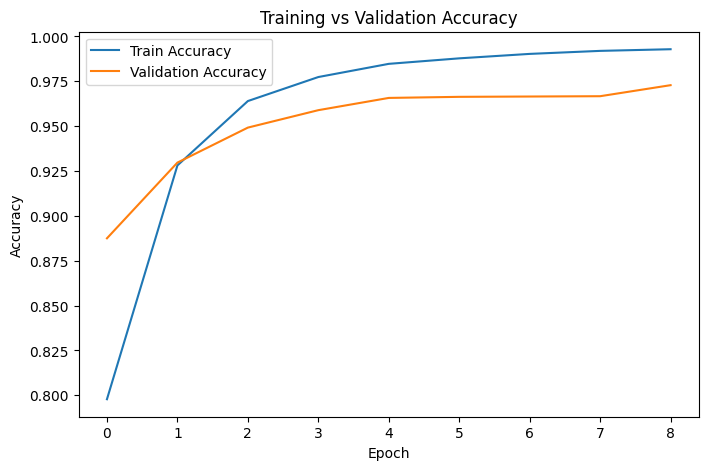

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

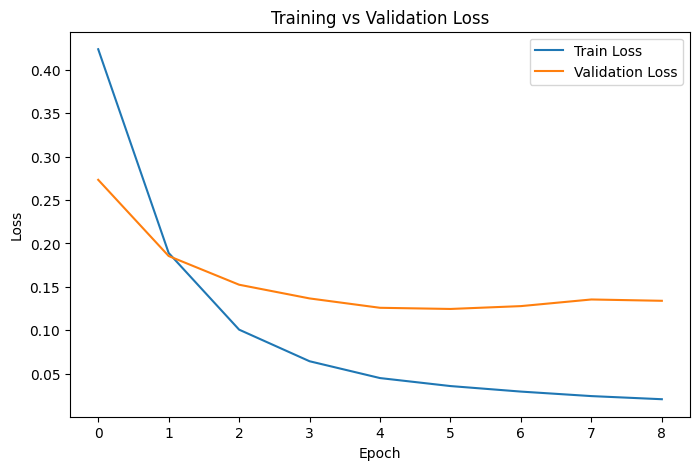

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## ==========================================
# MODULE 8 : MODEL EVALUATION
# ==========================================

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_pred_prob = model.predict(
    [X_resume_test, X_jd_test]
)

y_pred = (y_pred_prob > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1246/1246 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.96632033328314
Precision: 0.9690987124463519
Recall   : 0.9633589318877679
F1 Score : 0.9662202980265807


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "Unmatched",
        "Matched"
    ]
))

              precision    recall  f1-score   support

   Unmatched       0.96      0.97      0.97     19923
     Matched       0.97      0.96      0.97     19923

    accuracy                           0.97     39846
   macro avg       0.97      0.97      0.97     39846
weighted avg       0.97      0.97      0.97     39846



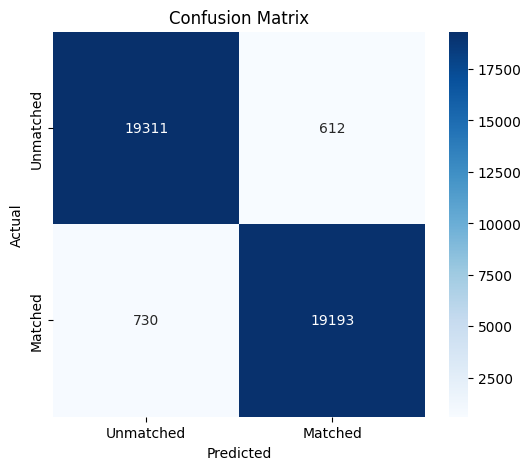

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unmatched","Matched"],
    yticklabels=["Unmatched","Matched"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## ==========================================
# MODULE 9 : PREDICTION
# ==========================================

In [ ]:
def predict_match(resume_text, jd_text):

    # Clean text
    resume_text = clean_text(resume_text)
    jd_text = clean_text(jd_text)

    # Convert to sequence
    resume_seq = tokenizer.texts_to_sequences([resume_text])
    jd_seq = tokenizer.texts_to_sequences([jd_text])

    # Padding
    resume_pad = pad_sequences(
        resume_seq,
        maxlen=MAX_LEN,
        padding="post"
    )

    jd_pad = pad_sequences(
        jd_seq,
        maxlen=MAX_LEN,
        padding="post"
    )

    # Prediction
    probability = model.predict(
        [resume_pad, jd_pad],
        verbose=0
    )[0][0]

    print("="*50)

    if probability >= 0.5:
        print("Prediction : MATCHED ✅")
    else:
        print("Prediction : UNMATCHED ❌")

    print("Raw Probability :", probability)
    print(f"Confidence : {probability*100:.6f}%")

    print("="*50)

Prediction : MATCHED ✅
Confidence : 99.38%


In [ ]:
resume = pairs_df.iloc[11]["resume"]

jd = pairs_df.iloc[10]["job_description"]

predict_match(resume, jd)

Prediction : UNMATCHED ❌
Raw Probability : 2.3927616e-05
Confidence : 0.002393%


## ==========================================
# MODULE 10 : SAVE MODEL
# ==========================================

In [ ]:
model.save("resume_jd_match_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [ ]:
import shutil

drive_path = "/content/drive/MyDrive/Resume_JD_Project"

shutil.copy(
    "resume_jd_match_model.keras",
    drive_path
)

shutil.copy(
    "tokenizer.pkl",
    drive_path
)

print("Files copied to Google Drive.")

Files copied to Google Drive.


## ==========================================
# MODULE 11 : RESUME ANALYSIS
# ==========================================

#Skill Extraction Function




In [ ]:
import re

def extract_skills(skills):

    # If already a list
    if isinstance(skills, list):
        return {
            skill.strip().lower()
            for skill in skills
            if skill.strip()
        }

    # If it's a string
    elif isinstance(skills, str):
        skills = re.split(r'[,;/\n]+', skills)

        return {
            skill.strip().lower()
            for skill in skills
            if skill.strip()
        }

    return set()

#Resume Analysis Function

In [ ]:
def analyze_resume(resume_text,
                   jd_text,
                   jd_skills,
                   experience=None):

    # Predict using trained model
    predict_match(resume_text, jd_text)

    # Convert JD skills to a set
    jd_skills = extract_skills(jd_skills)

    # Search for JD skills in resume
    resume_lower = resume_text.lower()

    matched = {
        skill for skill in jd_skills
        if skill in resume_lower
    }

    missing = jd_skills - matched

    print("\n" + "="*60)
    print("RESUME ANALYSIS")
    print("="*60)

    print("\n✅ Matched Skills")
    if matched:
        for skill in sorted(matched):
            print(f"✔ {skill}")
    else:
        print("None")

    print("\n❌ Missing Skills")
    if missing:
        for skill in sorted(missing):
            print(f"✘ {skill}")
    else:
        print("None")

    print("\n💡 Recommendation")
    if missing:
        print("Consider adding projects or experience related to:")
        print(", ".join(sorted(missing)))
    else:
        print("Excellent! Resume covers all required skills.")
    print("\n📅 Experience")

    if experience:
        print("Candidate Experience :", experience)

#Testing

In [ ]:
sample = df.iloc[0]

resume = sample["Resume-matched"]
jd = sample["Job-Description"]
skills = sample["Skills"]
experience = sample["Experiences-years"]

analyze_resume(
    resume,
    jd,
    skills,
    experience
)

Prediction : MATCHED ✅
Raw Probability : 0.9998934
Confidence : 99.989342%

RESUME ANALYSIS

✅ Matched Skills
✔ bom
✔ erp
✔ sql
✔ supply chain
✔ wip

❌ Missing Skills
None

💡 Recommendation
Excellent! Resume covers all required skills.

📅 Experience
Candidate Experience : [[['3 years as a Oracle SCM Developer', '1 years as a SAP Sales and Supply Chain Lead/Analyst', '1 years as a Cloud Adoption Engineer', '1 years as a SCM Dev-Oracle SQL - ERP'], ['Oracle SCM Developer (2014 - 2017)', 'SAP Sales and Supply Chain Lead/Analyst (2013 - 2014)', 'Cloud Adoption Engineer (2012 - 2013)', 'SCM Dev-Oracle SQL - ERP (2011 - 2012)']], 2017, [3, 1, 1, 1]]
